<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/PowerSpin_Predictor_v3_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# PowerSpin Predictor v3 — Google Colab

This notebook runs the complete PowerSpin v3 pipeline:

- parses the 30-day four-minute panorama;
- applies supplemental draws;
- applies all-hour, weekday-hour, and exact four-minute delay snapshots;
- validates the exact-slot table;
- performs the chronological walk-forward backtest;
- selects the calibrated model through the activation gate;
- exports probabilities, rankings, diagnostics, delay states, and a ZIP archive.

The bundled July 4, 2026 dataset runs immediately with **Runtime → Run all**. No local Python installation is required.

> **Statistical limitation:** delay rankings are exploratory. They are not proof that an independent RNG outcome is “due.” The notebook activates a dynamic probability model only if it beats the theoretical baseline out of sample.



## 1. Install dependencies and restore the bundled model

The script and current input files are embedded inside this notebook in compressed form. This makes the notebook portable: only the `.ipynb` file is needed for the default run.


In [1]:
# Install the small scientific stack used by the predictor.
%pip -q install numpy pandas scipy matplotlib

from pathlib import Path
import base64
import json
import os
import shutil
import subprocess
import sys
import zlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

ROOT = Path('/content/powerspin_colab')
INPUT_DIR = ROOT / 'inputs'
OUTPUT_DIR = ROOT / 'outputs'
INPUT_DIR.mkdir(parents=True, exist_ok=True)

BUNDLED_FILES = {'powerspin_predictor_v3.py': 'eNrVPWuT20aO3/UrOtraC+lQtGb8yJYSbZ0TezeuWyep2PsqrY7FkVoarilSISnbk6m5334A+s0mKU7svdpzpSYzJBqNBtBoNNAN/uazh6e6eniVFQ958Y4db5rrsng0mU6nP5bvefX6mBXsWJVX6VWWZ80N26R5dlWlTVYWETuc8iabVbwu8xM+YVuepzcsLdL8ps7qCH7bsqt087bhdZMV+3gyeVkcTw07pkVZpYeUbcriHS+wbb2YzNhVnhZv2Ybnec3SirPmmjNDR31zuCrzCOA+n31uQdWba7495XzLtlX6voZWacOu03ecFWXDys3mVFXw8oY32DYrGr7nlWx/EceXjwlLcTpccYQrT82mPPAaqH0D/cPo90ArqzgQWzfVadPURBihLRo56E15AsRVzU414Li6cWmf1A3wDJiwgbbpVc5huBexbPo+a65heNigTg+cXZenCthWbCOWQRf1kW+aDEZT7th7zt9u05uvJpdnGxPz9WPd8JFqCDzCt/xDumlwcDAaEBHbQfvZIStODSd2smNZZyTcdFOVdc0AC7LmOSHJBCsE75DA+nRV859PxBcShqSt4jl/l8LTXZY3xGYBtuGTOoOfQK1iPMvTumHp8chBLNuYPZMEA/ZfeFWyA08LKWTEnKeoXYJWYDQ9V7jZ+1RCStya8B1PmxPwlkQPlOUnQAM8q4FT6dsI6N2f8rTKfoGHG+BktoX3rM72oNt1zEAxbrDpBDUsrevTAeCaklVpVgu1BUXhzswB8mGMWbHlRw4/gBU/ff9HQxfMuMmuKg8sSXYnJC1JWHY4lhXgL6AXmnL1ZKKeVftjWtVc/f3PuizU74e0uVa/A4mEdVPmOaoR4FBot3yXwgTeZptGwMAQ0w0wv+YGRj3SELzJQETmNY/004jhTxBWkwrwIxAC5kJB/4h00Yvm5oi6Jp8/Bwoi9ieYHhH74Yg0pnnE3pyOOdfjBQ073qB4iqN6BEZkCw/gv+NWoK03GQDJ1zjjgF/fPnvz4o8//PTyxesFdbEqr/4JjFizJVtNX//91Tc//GkasQdVWux5cBGxyyfhWjX6e/Lmh+Tl989f/A2gb1FJ+IJl2w8wSSr8f8ToGeo4BwI52EUemA7Du8k3z16/SH786Ydvnn3z8k8v38BDwFQc47Sq0ptg9Yg9ZJdfQvfB6oJ+XbMH7PJxuAamAo/4cpeXaRNOXvztxxffvnnxPPnjsx8RQ3ARz9mM+dhDwOI/nTz79s3Lv7xIvvvhzz9h8xz4EIgR/y7C/kIF8fynZ39N3rx8RXSuJgz+7aa3aFMW88vt3eJWWAb6YypeAyvI5gAT7G70S2lL4LXm8dN5xB6Hk/VkMgElBCtdHWBZ+YUHxM56gRwC2SKPQjb7vfXngtAKMMnJWvBSPGvxDYEbmDs5wNIjCRbDhA1C8T7bSZCvl2wu8OM/MZP/guAvqqqsgumPZjI/JGvP3oEi4fBRLctiJiwlGGrCF08F/orDbC4UzQ/FSzlymsKJWg0DnC8LmiaRNGsJzq0FzTDixHEbP4cp+QcA54JWXKkRCxmdI1hOMER6eW34hwYXvJKVBdjgEqw5mGl3vYzR8iCmPCuIqUhFXPF0m2DzAOxouYXZupyemt3sd9Mwro/AA4IO5BDT9wkgr+UMox+wUq5pkq21JmAT1ANqajgNAqh4DEZrcx1U0//+x/b28m5BP//RwNRE6NBA2/3FuEgU2wBBBFXBFNqAYJVk0Txr6gZk+31pmIawaK2RoUD2gX333eLVq6/fPPvm93Ecw/pQ4fNTsUUJE8732ba5Rtbd5rwIoH1I40V+k9qL/u8UUQgkmoTssyW7GCBsN31ZoNsBHMUVw6ZR9rpgtzWYO75VKO8cqoAo8Tw+lkcpLrFaJ+UuwbVcQYA9uaDXqGz4dGWpILzUtj3AVstMjDEzE9tFC1ZUqv+mrLZKNXCxaWlFi0uGGdghqSDAw5vVfK1fYTtY0U6HIsEFFQwxNu8wxtjuYrFu6Q+qvRjWUox2ZSNbO7ConRr3csmms6mLDP/JVXyhly9rlfkepp7fALyk6h3MwCX7AzgULgDPvU77+wQMahkb6uUNuCOtTmruI22qG/+h2xuYk0ATF3rA/MOGHxtLh3GBhofdaD2F74QSy9CfC/4BXWEYj2DMrSbjs+oO/dlbLdg7dqvV5y6edmIFBUanAWjzXgP/1YDRgthrF/gHHz+U76W/fGrqbMvFJgQmsuzz14zlrOy7JwA5c0vtwcXQPWwFuU+7bmHcvRhM/BF/CTR5EZv+9rvFb1/BIkEvXLLcv6RhUDbc6/G2c6BT1ft0gYvhG/gNHL3DMXCGFEb9jXsb9jWSvZlB9uG+SYQZAWDHOHXDS2EDsPytD04KEgHlrz7kXYvRwrqil4ALuuU0xKjzieR9IP8PSzosIWIq1YFhsRCYpUmEcSV+GsLWa7WyqUfxFpz3bINbqoB2hM1yZdCCd/uW8+OSLF8Yp8VNEA4tzs8VMkMK7fYaJcO6tShbbhfRCt4MkCCkAfIuj0ucEqF0wkAB85ukPsH/+AFW2TRPaOsaUNuFw76ICR9N23l01tb9rtkzxM0K/h5nuyJeBRhww2h8MXI75G5ZrfPaN8t21DHut3E9sbhlDZMe2uMQsidXblO/I/dSMefnU1aRSG+NXCKjlHeOAyWh46wWwgzsTmKh63U46Ma8tskSkQGJVs6VWvsxqrvwTjtYp+OWtudSA6HL4400LpYL4VCVNbxqcAtZByR3qW2ue0HaI7hkDAJgi7Uhmdg+p1kEEUb+ZfuxYBEDCzCMgSJeBSGt4XKVdlcP7TkIh6FrNfdXan8xVh1OPmYVOyc2haxv2VJTD/8d0vot0CcFZ09+5IXmvc08HAs2k5uzlmvcQ+AL5RLgBsdMJsdRxtVU93j3lbAT7LbVn0O+pDvOy80KYaypgT5dW/Rd4No62t6XnK4KvsfsDtsr2MduEwqJJXWRHuvrsgl6rZJ+ZJuntbZPP4FtwLAULGu8ArBWUFPhpygjE4pJcUURNpUzd7SV0q6wxttnoLSnh1EaDC8kGNLEQA1uLANcDPZldSP2IOov1HATfZGr0gGMFsaaAJEg19o80F5B9QTEy6dysigilYHTq5xEOWjvnrv8A44oQiQ2mDfyyd00tHeGqg1NAHxgR1WG10m3z8OpbjDA3qRyVbl4ylIRSdZB4prNf7eYz+F1VZ721+zy0eLJ09YSqhCuFKvWyv7aCklx5KTOy+bT6ibGSJoMrQ9K7QDWqJFB65kTqnbG/kk1UsWUYKVEUyvdQVDDuw5dNSD/f3T1BXETRdee9mPU1uJcv6ao9VEBWHxa287iCG+wn1qp6zXTCC0/USl1VoC9zUhYYheJLNaRg04CkXIBIbntBUs1uyX2MxEdQYHIvBgKF7gk0avV4slasVcpTKLcJCB8tFq50VI9uDbOddyUCUXYAy98ij7gkaQi8XzN5veTj86MbSiRwa6Aj3yfoiFSQsG8TkJwSKfqCRyFeUirc/ohq5cXbYLsVugsWGRdpVtrwLQut6FhjbaVsCkpKh4OTpR0cy1tD40PnQvHytI7cPjRGcH+QKRAiS3Olk11tiCu3awTEAomMeRunH5dsOmrEuBe4x9TsQ8s3/EqzXPdcNFjWAW0TASOhLas+r3QL9CbiyZk5o3hBav8AxBbofPYVKeC5jx7NJ9tbTUhX4N8+Qze5iW4rNXsGoSD+q2gtIX/+PmBbnKLhWj4UFXdNQMRJZHabbTb0I4DN3FBy7WmxVa46rQ/KN/bLs06XC0u167jTqKOCYZ0ol7h72sZB73n7G0LfMzY2m0++dhUB/YY5bOIfcRgO/R1zHg7mvUOWRsNNDBqzJYl6Rpu2zmqV7rBfQcqDAYtE9Ai6aA8MMGfdvDi3BwWExaD9HrCfnvNN2/d6ehNRpbucd0V+XiY1ryAjY2Z2WAac9sjsyXT6ZXdTo9V+Q6sBAa9aN9+Z0wg8KsB21xI20jj/FRL5YhQl+3RiMciM5/ARl+phQ6D7cGrPl7dBFO5r6sxyRmiZJHHQWjZWMp/0TI9FwtFtr9uEs1K9RicLwNpZVGMLg8q8HjlxWMytCNcjtDhOK1RRwNoZDDoPeVIBXcaSxVLYAO0pywWmphOfsd73gSalAhchtDNE8l+Iz0kQX+kCRR/I+9+yY5uILpNtEFimusGLUMhQxpuryH4T+7YFh0pFFshvljKvNwI3J8JPrkD68lXGE1SIfjb3oyFs/MxvO6HN8Ftzf5+YOtkFZeRjemia3wDOJSBcpq3+NDd/C4ckRdrzcYhmbQ6HSHvf2dp5HiCLbnCiBk0d0fyrxSHWgk0jL0kYDTMtJ6ikZNdOAEUq4fpLqswle1u4ANjK3GHMF+7ttBqjkfSzrSeXfQ3FzMa10E1rQGFM83t4Ti6lvCiqTJq4L6wWijlEdsbgEQ2GI0KO0AJofkDtihz6cHfSRdjC9TeCIwJHVnsyof0ZD7uuY4Setz4aToBJZ02hDeBaiSCyJg9Mk90UNZM4rjiInAqTfbSLPIRnj7MRcB1ObeaUBxWtEprYDCddxEJg4nJXBKZMTg6vGqCudw/1tNIvrA2qo4O01vJVBXBStQQ6KzEv46z6HDUnR4J8VJ5JMJ9UrSpAyDUeCVRLNnl4/k6JibZo9OyaIspzuqsCFykoRU6JB3L0n1R0rHYXh4Yb1SH/5aDfFSjUdEELWbVyFKbmHRBhgWCUOtOr854no4XA8S5p3oK2YOu43hEzHWW1D+f8PipOpsWBIIO4xgBAzRqwPWAXbKH5oF9im1fltuC1+AWaXR0ADKGfi7jeheY/iK23S2RSuukIh7+UcemymrLhcuphtGbp7B9YdFqBXaav8vKUy0SJeJpW+1sCdTX2a4JZHDnmIKdttph8qNITQ7ZIJdTskoLeTx56RgNQmTDR0w+MiZDS9tyejFTaAv/nBGxdAAUMYPFDRgdqd+P+rftLmKJ9KWFUBIMGoGd4cXmxlBgBoR9V5U4s7s0h4RcIYndts1qO9UWbxuKIkzUVj1Rltaxry6qyGAaYtU9GEM9E1vot6P8/1iWGMJHskQGEoa4Aq/LHcI5MbFB7misn55Bqn/ikfrjaH4dyylnHMPM8v0rY0lxVUvomKr0qrw1Rloey6+w7PyNcsaMvZUrQnEqsp9PvL+l6Nvy5bQhtVtoW1fukl2G/o7rK0+NrUOX1xg+F2rL9xXnAgv8si0P0nNq2cVWs6MQIMAam2tA7iw65dQ3R/43/Ayt0nBrQxKOIZmCb8rKhL3UOriPYTfJNNfSui43GW2zE4yzpCiDUZSrmT6abmkIzlEt7EYb6n1aFTAHAGr6spgJMplF/FesLPIb+wIS24IuVQc66AxLA7oWmA6lzuJpN0vUpLIQj+KFNalHs8NM+HMc0VaiR5DOrBJuhUe1ExtTU5YcENzPqDfrobBZu2+9eRCpDLBAPKDfz57pn06nrzdpLjO5eDooT+VhesYx76II+JyuHAFi8BrT3Hhe+/Sog4zUsbgfkJf7i2NgXRSQwR87qIrTXIM6dy3CNrpNnh0D+jtis8v4ScTgh5vaIeCZlBM02ZZN4DuBkQAMQ4dj1oUhn28Ru+JNKjWgj4l/5elbZEpZ4L06YFCT5XhdiM68YHy23O2yDb64SmtOJ+fFioC42e/ZnOFcqfFQyOeY4tie+OeM73bA5K8EzNcaBja/VTOrTgXb5KcaZhbd8ZOECH/OugC17HCFwT+GMQC5AaF+4CuOu5cyV0UszKHZXOHhVXU4xual8UN8rjpL8BCMxf3IIHzPcVsun2OcNv5yLjNfbfEoPWr5NgJDa/CGELNP/UJd/LGaha12/kDsfcq95SGUdLQImmuwZ0nO3/G8TwrtOLLP508uJ9GlL6gn80E5PuqToyJCCm7JhFTsblwh9UjfaeCKsc0lWwnuqzQtcv9d9OU/zeVC+slMZluweZ8DfC5XL1vM1q5CvsMrhCtMOVtQ69YOcQSwWSwllDjx3gazspYeWR2ZTQ/GS6XI3mBB9jurOS/Iq1ZXaIAk8Uae1Uso364Teua92vyKyJYFAmOXt3P+kzh/4M11uRUcgEnMD0eYrJu8JuW3Dxx4mToAchMmjsyWMBY8BlEHLbfaXX4jL6Ws2oubh2wcGucqojjpevk4vHOxe+qw9OPs2fbD2D69tvJmqCGh1dxt0SLOqN/Supwb5OnhapuOJamLnULLjDiAMVF7qzMolA6ttrB9iZdI74fQmwIdctDB9I+Shkl5dp3cGhKHnnnL1dp9Y828JWaw3bfuvGsByP03zrMrvs+oA9iV5Tu8WHNjXfV0M+OYNgeg2OoZs33btHVfywMiGB/EpbHrmlqGKYAbfcAQGxlT5HHafa9yWFtcTfR4jf3PeC3HLCY4GWPn6JAtfDCLxJFOG2lIkabn8ss5uup61SHKHLMESyICdYVmww5s49Cdw1fxjRQJhdYddq1mXy7WbUgdwMZYi8NvQYMxFmDyb9ZC10Ua2+qrNe3ua5BD11O9ePTEZ4ZlsOU5pS8YAj6weOjxoY3JHfQQAjUTWhrsnSVpWXvRoUE4cL3Ca2XI7NZ7b1FZdVDYxZae63G8qPlBhCJ7up7HjwcwfQHvL/G9Epr/FtXViMJ7f4HvXT60LZi7uCid9g6tTfqXENXm/GGwSd+yoVAMHU7xThe5kRUKJmCK2p+9Mr/RCsVIpjfpCac9xgGNqRgCdSBbgDLGfQI+Y5pdiq0FJOT1pYEzAmxBWpLTwK40Ww2UxmFaWv7aRaHYOMiwQIIu/3yOuP2tngEXUYvlPJ4/8QJ4nuBH4fYmoY/H6tSdYy0KWiEDv/dzMYVuVyv6CJIsZkj53ovPsy5Gt0bh4f3ko5ydHaZ3X+RXSb6NZSyTvd5HsHps5+fH7kdJ/MGPiKQM0/JptNEnw+PU/w2lg1y9M06muFpnum251qM9zkhd8lO7Z4ARgRHfOfd9wpXTeO0eGOv2ms43aXl8gw36vST/LPQ9/ZjzhHqbC6eFcR9+w567N0TwNIS660u5m7PVw+q4g63Oofke1lswLVGv9WFb3WLEcXW/m7ONzvc7eG7c73EIfNXRl4jZqvxY9333K3CZkkxFoGASQMsvew4njT2gM+Y8iXdYRxBOSf2ugzyH9Bh4ZbvaqOyTAW52uu9oAN7wUHs2cT3dy2pTm4bHOrlt3+ZU7UMsL+XwcrAaUQNuGF3I1CwlInCPJ+YD9ESlnhDlDGs08iordfED2RF5x42mYbWwCVhLP14dqjdhvlgEAK3clxOgNL9RPJK2jGuq9WQHrfTwVPTKiWhBw9A+jmDd4teHjs7e4BfhDXVdn34E7oZV3ZC3bvTT7A/buxILUD4xII7+WYDO83DoiH3slhIQ5+lN9MfpTaWlS7q/IEDdwIkwHdqS6P6cLbIVupFCd+09VWZDiSeFKGthBfqp5KemAuVw8G7BtJIDmMoG23Oi0/6H9EMgsp8WRMv+hBG74LOLJ2FHFYLirbgES3Xy9jjtgpmTO/A24aSjKzOe9Wqal/skL+saJqgMRs2wLiImeYNOwsNxeK+qjFcGaecZZp36xdCN3ZvIM/MbPyzcZg8d9usgaRyRTXm8MDQKclw1FvFpZPRqcbEOR6N9NB7to3ugfToe7VMbrZgf0uezFlZ/drQWW3UMCouuOBdp7Elx4E2FFVszmdXvmAt2GbrJcPmiKaHGY9emiw4gnhaJVt6F0SV8EUiKbPUOwz4spKoizdePSOpzJxZUo+Q6a5JK1E3qQSG0rQ/Do3EYHvVjeDoOw9MeDJYts06WjeDkXSsMKuNHtt+D1r1dPsmV4JliHt5Vto4T0O286Jgz4GNO7LZP0VseVscJ+yEPy4A7Zy+dE+F9HtYZ/8PyDPQh9n8Xz+Ajl/r7GK9up8M9eIToVElV/gE2AqocDh2r7Hbve8uM6npIC50Zl8bS0TnhA+P1AKeGkoU2XA9WFxPFjkWainpY/Y/+ravEGDo1oo1QEy8l7dAhIc31Hq2IoncqNd2iXXVvX+tpNZNdUesvVGtRHFPUI6mXj92DXaLodyAv8Rtdd4MQxHwqfLxqVR3zK6RYl1w/rkKOusjuroVq9+qvkF3Vfu3KCwUZJrtq8Hw+s/568tTUtrL7VsvoSpQ+f9BzC96+gaGrNqy9eZv0rswu/vNb++4Ou9cG5waTWSXsYZo7BapwWtTdyB5IXyOlZF48U9zY8tStd+NudOmjKtgobdEjWlk27MH9LhJ38HpkPn89uFz7vFTVmK1tgeBf7016aTxatjOSB3ZyOpGakJ8ngonORHPrfPTdxZc5effY269o2luY6WzrIWukzWXE+i1Vp906c4mfVi4qirPsX8Wcdcu5QyGXa43FOBvmLooHYxb+MYVY9CCiHolGPeKKetOYflPrDJ7tZRiaQat2VGNVVVxtndfL+K+LH4jAsaXAKozgIGlHr/6L36giOX8u3hbl+0JjEdsdduti/awy1R2tazdmpk66N1LWXWbrYo0LonuyJjRWfbUHsHLJWUddSeFBBCpxvPZSS8e8hM0Ktle51GFEOvm6Pp9zHULkb30GEqsO8Hp8YvZ+BIzI8A4S0pOfvR8RZ5K8gwT0pinvR8LZbOcgEf35wvtRcT7vOEiGESJdgD/rnZ1VKo3mfk7YGRFprGMdja65L26XJOp2SbJPj4DXuRtipx+NtXYr9q0mw1bJqRFwxm60r2n1a0LH7aXxLUZMOa+ywZn5YcGPU2XRwDrbR0uELIoYV/yYpxtY+ZwmbIohwmm4do7YtxuvY4QKxInn5RR2a9Cyfee/s5yNumVqL/mtlZ5SIO3dnoaxq/0o8CG/vWdjIYsN2FvqfqYKlkTGb4i8rVfXQCKbTGejcQCnLWilwOkrJuhVqY8Sxc+q/QmLBtOXSapgy+tNlZGzuUySbblJktBqGafbbZLKJiBVWbsXCyvgmUTxPZRrnh+XU/wdb4R1fezkzd/eYH5YFxXsQm4UcTYTLuRsayrp2aWxl26REdH9cypCLj8NghVF7C+ZoXpF7O/wb/bq1ez5c3WhcGCosxm4M8cTEJFV7nBltoz+ApZgFZb6CP6ygE/ePZqGg3hlXnBG13ElZnHKQSL+chyT7JraM13vwqfTPeQsuKW2F+zb138RVf30l6JUKWm1oatljfTmOnUroFslXc9x0yZbKveMFHimcPwK0lU9ZESmthhoSwVmHNn9CJM4Ph1h+HW3T0KZqWv56Yjrq9MLxH2lC/tuSFh7jodTgM2g6luXckwC0neJaADim0n4LJAm2f5OjfiWBX3lIKtL/HxP2gQIHHs7Rnoq5xPMv/jwFn4GgJ7jBQya/jCADNqUb1XM3vmsgvvxJkKn/urYoKpmw58biARZ/utwIISAVUc6ioKLAXa2CAeiCkPYuluEw4EGhbC/RLTWI+qkF84puKJhZC1EUQPkfGFELYuIjemI7FbQ0hX2kFk2uZOWGL/INw3j8sgLa569h9nU/qKWPFaW1gys3za3TmYhjnh7OhyDzj4i2QBR1vjJQHBkskw4MREVMyma5aVyXNRBHCzheK8Ch7INlqXBmtiDvHg0R/UgcICdRsxO0MhTelhYiiZqZ4Gp0ACN6tFCUydO8TKiQHWqKw0BTA0GDC2KV35otMitlo6gO+V7RrQ+afeSqzq+ZY3LPdHlnuFa0rjsJ2EnmlG8143ePeoSN7mrIpKCKbyl3wlmWNoPVzJRTlklHWVROZyJ/ELWPhNBI6+15nDQgdhJza7xTJahz389Y/N4Pr8we4D/6EVq59oBr4/WAQitMHUr2mZvXjD4roZqcliSO6HKhmkIyofRfRbNNsuQ6a+YwmYfyFe9YR+eWLy+JiY26wQZ7J1F5zlefzuBK2d3oN1YZuvwmF5FI/uso8Wxnh2NtuXLniCtlzBqNfvVMdxlf3TXEofPSzXj3MWwb+ppvrtIOmdiuxYTUTVqglsBmUQ6dX0TXfGrSFuRavUwCGOqJhl0OB8jxr6zyLq1O7sbR6XnPIzt2FvpHwtfdmyP8rNMh0NaofLf2lUltXZj6SHzV2x8V7vwUUc+BNoZTg+0Ik1RhzMWndKJOmJV6shS35SbdlkVqjPqP/bw4znz6kSXjtyAzfQZ1uVBdz6lD6sKYyYTCeJc+I5lDX7pt4LZXdMnocHH3DM03Pjx7bRhbixzmnNM1pM9py/YgIBKg+AbtM7ikNdXrIT+qveY1qi4+ngK9G99es/mlZjisC3KikwWB2qN5vuur2PbtYzPH3Nvj0Z8M5vKuXR/NNv7CsMJv+qsPwduvvfdQmzv1TawCrzt/P73V+6XuDmIpm7kdTR7ZIMsE8fguhXgOztHNaOkHQqNt0dFOMS9Afxut7nU0h4XVsGpVRkcXQLHTZdhDxU/iA856GAsOxU5h3FPvSjxDYagxPhTobDIpj3FiE4NyZtqUvVwwd/jJRi+ksVl+7aBqPo978TS727Mp92rn9dTzzZR99az8ezqsXvh9Hrs2UrqHns2p1099i64qtPAq3s1vNH0vqM2DG6I6hR0x1bU2sTpSsDtzZ01X8xuA2+m+fsFA6pcOYDr8ujp9H0Jxg42EFP59cdpqGp3jdz8yLUMXY2P3ftIVPfa8BwrzN5rHLVBMtgYI9ggyYRWuyShzUWS4GxPElnYRAS3J/8LhPuNDg==', 'powerspin_panorama_30day.txt': 'eNqVXE3OLclRHedbxbcBtyr/K70KJNbAgAkgJkxtGstCMjBhxAQkM7SxbHhq2m6rd3Dflsg4P1m3ERO6n7q/796qqKzMyBMnTkS+17+9fvv645dffPnp/v93r99+/Ojj9a+vbz9ev3/94fXNl59++ccvX78+v7798rcfX/7u9f2Xn338yV/+zZ/99cef/tWf/8VH3Pr61ce+Zt/98frP17f7f/syXP2T/eH3r2/2p99/+Ydt+vO+9vP+ol4f+9PvXr/e3+/fP71+GYZffwxrv//yi/3Y/ZTXf7++3yZev9k37Y/D+u/2N7/eH33el3/+X4/eH3+/H/796zf7i/3Jt/v+7/jreY/90TdhaT/p/znErz4wxm/izq/3D/8RJj8wX7/eH/z9viNu3t/86sPXaUp+OOj9nz3Wr2H7M4YZ77BHvIcfF+Dir2MZeOXbhMd873Hs1doj/UN8+bN916/2i/08locDi5f6vxbuJ7Dz+q94wY/9iJ9jiv8YKxYTHPdr8vejv/r4+PTp9U8x/vT65f78d199ulrCo3+6f6zx4+fXd/vHkl7/Hq+2f8z7x3ijrz7VK73+eX/6s68+lZVe/7IHum8r9zFW5jFWxjFW+jFW2jFW6mOsPMbyY+w6xvI6xvJ9jOV5jOVxjOV+jOV2jOX6GCuPsfwYu46xax1j132MXfOZs/HMWd8v8uM+049SSyvtJ/aU0x7vHv3+cb9vSfud0jZf8dv+cu4r4vuR8HOPu+LPSrBVt6077VHui8q2uidq313CwL5of7U/mPvffUs8ZD80xwX7lgEzd/wpaYWxtrax/X08dsSlNe6u8dxtOx4N4znjWWtbvWGO/517iHFBDCYuH6nCaN9GOwaz7e4x7C9aGMULxjg7xoLvNO79NmGphv2ZYvT7B1rLsIYh4oowODFB22LV+8Xgws4dz8jD477wrhlzscd4hcEai8EJ4Yjavi8GMGBzbkst7h+Y2RhYPCb+id+36QErsQwxQbf/hKEehvG0rHG2bWdgdmoYGpirC78NfRa/bocoYbZoQTqWHpOxb8Crl/idD8Sg4+ViYLGmdBjOz56bbTouuGGxw/dmfJLgUyOmc+LWKqdYGOGMYd/73xhyahyVzcQyFM5+52PytD/xNejJJWasc9QxYfHosNfjmgkTFY6cYx1imBPuHwOJZ++HZjyDzktHDr+j255VjZGG34c9mMOCDNwTb4LhwVVjSPBnuk9MQwxXXogpuLljbtm6YhX28+PB3D0xq50jwBzlbO/Yvy7t3UbHkQskLOgV0y8XxW3yxZgQbJltBvug4o1WDD9lbaewv3cL7MT877khGnStF2deUxbT2+UZ1ZsuXjeHE1bsu226bTwlIglvMhZs8DKulLy/EpuwtJivHtPbMelw9g5bFR5WMse34Ddx87YhHILvZv63c8qWdnQBNMRklJihGhYBSwVLhGmYcDvdDTvYW7cApROccrx+JcaeXTlhLxYBuFqMvQXLWgIxOKJOCMgYzA03pq83+hB8YcFaJoBwB/K1uTJ89xqTdGP24zVjMyw6IDazIL7LmuGoVL4HV8RImLPRv2oV8kWUgT/RaQrcRGidYbQCNEvGzqEvjUQIYbzQzoXn4KGDo1vw5spZTiOMEZPwxjXuYJiQ25dET8PEwiRh6WYUYVyLf7GwACOs+eBMxSVDG+GCGQa0pf0CdG+YtuqJld/D9wBL3KJYsQoYzxxejCimk5DHGFd06VTQsmffwLlCVKITYGMM4ElPxHLGx3IJ9YZ3IpeNoYZ+E1gQkF4ETAxAibekgLP+4HiCq3jLE/5ivbKWGlsWoKTICy4RGIhQURqfp0VMw8CHlcG2XR43pxf2ugAzJwUVgQa3GbG/af67Vog/hO36NnzuMkBUSgLBKielU4slwNnCwlB4bYwZzc4NHNjDy0SozHjEaccqwH+11IB5jbkZZANL8ahJ8Ipgk4lRg4E0a0SLLKD6pS55FqL9/s1B8cFJxIswB4Ba5hqM73L/leTe8LhwyAguJSdjZgYyTBK1XGCuwxwciitLg8Q+fEDKVzXumTxjNb6snKiGhcgCqOroAIfg/iAiaCmxBWNSq+KQ4gjX1PMbpCkLpbjx8HwAnsEEH5IpTe8oRnbElDz00CyrfOuqjXFz9Fw9eLY3HLZn0yYEasfTWnL0IznCAAlS7bjlTVNiMdmwBE8pwpVbeJoNVfz1hscUrkmOaRUZI4srCGyNeJVtX0AFEh3BFvClF95XwyL2R6lE5MqXWYkvDIwjzicQUkEjd4iAef8ehoBRw8yrJD0JbxCDKE0Mh2uBvXHxEgy8gmhw3oBOcFMu/QIB5l7gEuLlwFim41OHnTRlFuQhjBGiEAoXgQGeQbe9mf8oRIBEECSmXL0YMppRENNGnLrkynKgGyx9mFzQoS/N6uAr34kJQRUhwRgC5TOhqiUttzOgIj5wPU7hnOpMLWDhYk6QSdz3KC/B1cW3TtwGfHhM1hspr9oWmFaDThdy3TBVtX0ns0AC1CSKlEs8aijGcCMTozE6eF5/C69hsyl4xDRgjZk/HtLGuYlIhDAnyHAG0AQzsNTJHAfA6lZEmnxw8XZwUAV+NgzIGzF7rWAtc9sC0fA2yoaZgYIBgk10YTpvv+njyg2wqBcxSolRRwJK2Elk+IrdWXBEl0uF2VlJiqE3GNQlcCqJhL3yjuH4e9EI81cyMmY/Qz7KNRMd5RKYRsXAlXnI1bvzn4m0TJsEU4mFfvNNen6Bva7cHbPTnuzYaekkJHEfi65MBVJkwwSfAji+RKUuDrEQDJHU8k1Iny8BaqN0gbysOEFQylu5CGHTOV49EDyYP4kAnzw2XPPS9KfMr0kIG/fgiDToIlwNRyZnFT2d+EUkQDCaSSG5S3ooWq0bnDTDnQlZgzGnYv678i748K3NL8ZAn87eGTOJmcBUV4pM8lwp9bSkbUuikPSqQ5BWznYg6plLFHghcGqlYtjDpMyURHATv7kR+w+0zkTZATkEIOdTXgSoziSLyonJdamEM+w4wNVl9SdpG9NtQkKCKcQM5ixKzUgknPg5c8FsTb0XbieNEZqXFNYATc1KC3aZzIiGKHu0PiXiPpT+ZV2CjdJgkIpHY76vlJ+cBCQrD4lq8a5dHhs+Z+EiHghD+SE9nUyAilu2cuLs1tkxRlwoFQXwCPDDucIgEaoqwFG76WJGXYMiQI2H6WfuYKRvYl4xRtirHKBSkOsR5ore7DbvH4IOuDqz6eFtvUQ2wmThaoSX45FHBcpii1TuzDxKsoRl7ng7YcUICVIgrpeAZCUKPiPRQxeCDoeNuWyWBqtmIvA9bGUnj2IPnXIaxB6iZVU6rzsXt4tUkGH8v/hz2ARALb/dPMnsOobOZtCqncyAqCxutaEK5iqHyGDQ3nETIsKloOPMaWhU95NKLIZBeYwZFV9RMkJMoNIYaLCF3BY3F6KPtuuiwxIBiE9iL9lyYQzUs1UlLjHZ6UaeQnSYhIGAprCWqZFBGFN29pimfKeQy0BCKK/YuELqpomPfXufjM8ppqnd7QyB3Kcwj6ryqWxczwzEYuMDFqWVLzEz0rtwucHF0UApElQmy8jYRC8gFoYlgxSVo+MIQ0yMeR+hJjNacWM0EW7s2bgGxhS56eZTTLjK558sm2QIdIdBw5yUnMFZf8f+uAlXRZ4gh6pSTcXJu8Tw/qSH9UxsP8ISeESYrFJDrHCMhyGTYHB9uPyyXP0dyXDT9IdvwWQVE2U6N/RGl1C2JKdBKldMJbhTZQlJT0xD9mjCZlEQB1ZMbcgMtaUKoLKILMY/jWXiaJTStDsxSqnmRc9dSkum/G0qHJm6A/eOBFS0Qk7gJjbgLYaFLIjGCksWGOZ0jDewgW7clkjgX5mPC1sALrN/TAQRWDuhIimjqJnFDpxjJKdQiGMwVoGCiw+VtKt0tyksVtFC+FNjRspsXaUUZW1hj/p5fcukhvy/O2lvEmKXnUfCur4vJyWuIog03Oni5GLdeZ5A5075gKCqJcWZ9LJ7RiSdsJUldUCIJ0lOj9wPXVlJ13CuLjRr4lkY8qc8A7puTe/wPJ1KyC1BklFasuNxVJUjssVw7AvYrHpD4gCU6IYMIxGbQXDLCXr1rSZAsR+3Ynxt8TVccpqcjWaPaZwtvmQ3R81vKgvV7bRgrZ9NWg6Zw496E7AHKsWYFicexdo1E5kItzSYk0dOGiYO05U7SP5BLBM+QqWDnR5YPwOqiLxMaW8JPcwmJ8ufzYyxCV+hVhZD4M0aUIU5Zv75sNfMzSF20VRNwbMSwg5pWpVqMsTwZxgrS7lcXDxOoO9SmZd4oqkc9+3jJVQFl2F5BjqB0DUJtKqCctIbI55FHJIvbYD4OUkRGpp86BoA/5WkLSgkVrH0ph2EoFisuSwSQCo8hMMe9giKKVmTnSbDfFNRM71BZzRT2OzIaGCkikdfRoumovAlOQGUX+kS+RpofmVlgWPH/8PcteSg2VrySvQMJ2NF+9QYXKX3cBuT9pPX0GDX3hynKiVwFg526YSW8Cdp6u1EtFnfvRXgG8xCOmKGSX9bYJiyX6nNqHw4LZq5/KHQs+nZCESqwlwCpLVg19Sus5He6szZns3ln6ShI7CIGFGp5tBwOY4g0YGO/NSoyvX0C3Svcwz8DqNtCdqmmSDptKrO9i1F2KqqKyUZIiFFPRDSEaikZJsRkVrnU2NvzjMqJ7AqfBXStSGtAKayAYtK0u2JY+otB6sPlpf8zAfjIxY7bNWZRGofnunWA9CiATqqgOhC8vA2Lafae2lla5Ve4oaRijqRagDanM1KvUfaUByW/1XjOsYbRsuyMD3Id4SRt1ARHkHMU6XmQR0CQTwSlkihiXEoyerHStN4N5YFqyKq1YZLSEH2XGAtH30ps/RH2UqF9CmVgoutJLBw10mDz37ZAoOMuqIux3G5ahRElkTNdmpFnjH3EWg7LdjDLhn0k6WITlgb8mNFm3Y0n4OmKA6ILpJVYgqv9dTKlWXMw2w54VXC5nRlKlteJQiaRmNxL8vL5RR9VTGXIqKvnJFVAYGyus7MkJ7QYNCCVnbYvmRDEUsFL3JrqyBdQuQS4LDoniWg5R6YZW8jh5J2x7ed3mikGcqDO20YYGZyPtkDtBa5dHN8BEtmPOvMiBZBvjMxLta0qgVdWGpLgahpBbuZYLF0t/iIIikM8rqYTmHVj4EB5tBGoTT/MoshJNR0K9xkMScXp+BhuarOhsDWA6mU49/WUl3xY5H1B0ihShC1mxMcboIoNKUeeGWY8vZRwCpuKbudKqmE9tS+xylFiXyHytIDsogQDA+FwgKLq0yg19PTwqofCulkxKpIBGvvAVSu1E3WONZZdHBCkmJp0NJyGEhu6eM3WFQPpHLRiVTcJd4llUQyC6joYsNT8aKVYkaNTdZ/TIp+SAQjALeRjBUpFIqZSw9qbrkRloY3YHwET6Ugt3Io9UmceqU7rc50ruTuN8dP7o0BkxUIz7ysKRedatkp1MvMjrpq4YwLNenxwkn4yrUU/YcaZMrpubuAo/0Uvpfrfct6jSSU8woZW43EqmOY5lSKmW6rkJa03toHq4QUac54KVjLEgw8P6qikr5QM76kgsEzpoDwJCPikoxWn3ILkCqci/amIkjs7ZLmqvsuqoX5SjVWvRYwVIWHpBRy94wQa5GDOc57hVNiJS2T68BaW6oHl3qqUadlBXv2TcVm5dDKtcJFPdVitF6Gzf60prlDYiT082V3EbhecbsdKKtgqfyeHSA0RwWCxcAqKQCs2D0FU40i1QWES7OhovoUn8NC1ImyR1dZeTA9UQMSeyrvp9jS3/QEfiWQx1AbDKok3z3nXIGuyKUGtel2BGX5GZjT1XDopo5triy5ZnfN8ylF9lNKaMZ+pV3tEO3iQiFnr5z+sqc/yBn45Aagt9wWZE9Eh3Ytzdn+QtowSYULiyVXmqfgzw9VXyvsiZtqgKzCWpU/MTzeN/ly49RotKJNfKOqSbKd+kO1MjIUS4gSmEGlaorJQKymd0sKTKfbimXXfhohpLSYxjXuuWudzpSqht4jY7DafPJ9JYDKM6dWyc1l8CRY1E5U3YPNeJY+1LbMaJxco7nSW7UG2w6GjgZU1PRK9VSSG9ghS3dDy9KtGLW3Os22hX7z947jfpqki+uNS3dnM83T5KJ9yz/dzSewqr05T0U1Sdg+TQlqSXm69nJShbE+ogK2Yg+LzaIIlSZ1XCU355DDTO/cYmC5xIdFQS2Yw6JYICmZmY/SDrWP8IpqoVt85NIcmqMgJWiw6foNHEJNDaIARdR3PpWTbu7wVuOm9cXkN/ZzJXyp1HlasqyGliObO+PBHtaOpN8zZQ/Shm50t91yCEzYfpDYu+asrAnCI5WqKvCKPY43LosgX55WSp44KO1NX58OnDl5v+T11sLqa2PTwCpxDojI6XHRSBXLpnq2UL6qXa2eeYGV7MJNdjeMCvEgN0D7fqp5rPCSW9UnXcL+wKuq+3zJSZT+oNOUDXlTU9Ppx0N+DMO36BZcD1lvFjeb6j/QPNwmPf2p2UymnYn9j0vuKFIRBq+lVEO5hApAap22jm9sJDxwk0xlb86wg6GiFT27LDgta1k9Nk89daZ26kPF/lFOWyPbZDLa0rsUVXeiXZSmVW7Jbq0ZSUrsqbVOVaoAaJ8ymtKZNFOPUSWAlZwlNyaJnski/BACLstzDCwJbK0wB2xHsjm5p3abOppxPQuNKhirzQMLEtkCetIVqPupCGUWIfTIU4SnvPAkvlwSl0ODbKAlHewP7HqKiRNI2LhbXJtsSW0P2f6lBlBlrTSnnpnUxJe65FLyAgXE/Jbmy32sOzytWxyf0sCe7rP0pnfqJhIBmuRzpxDAujn96fRaYAYhqZemLs5h1aqrL51Bl0LZrSKH+IcWAssWlspK6elZvf2ULEdgSlOoQvnI0K3DIcp/L0eDDoPdLusaqUTg/FbhzMSVIWRNWTLUdIshy/ADBk/n1O0uj+LihMP7ZEl/nASUAJYJ9OJaWIysDpBz1oPEG0LondJJlNy8Mv3SYESXm2ogyMFeZfncDY9FvXwkaUr6mcg1+eXptlZDmjuoc9i7lhBCB6fO3KHBbCZr1Aw22mZYbe5A7P5Ls+tl5Du5HWZ6S6qh1u+cLAS6NfqG0IdudMZByQusSrkBaSg25+yCzJJKo9Z85w/bFnrRldleOtV0iyBNJoJFLP+2EFIUNwRZp7sYzl5hk8jUj+IgB9LBgnJK7BVSFTY0oLElZ9FMfcJYc18ToE7+Ol3Ga+9sMVkmnUdtaKdyEVQU7ehSaIs6PGbSLmNV7jSx2iNZliOgdL4tDBktqznBpaL2eqPKCuJkOV1kXuUwMXGo5GERarpOsT39Oc01EDOCeZCmOLMiW3CmGZsF9qQOSHVWfSm7GUD9WLfCVmfK0U/NqJ1Tm6R1WUI6S+igsCSaVoHYeTKYBnH0bBNUXd69P9j4WWL6TX5lVTQxIuT2DuwUi6qPfFYXDMniO4z5DE/Xzjf9rUk4NJhhF0vqGRN5lDamRGEqM/cm/g92aBqGdbJHdFCdAuJqbqEwX2RhAhatuA6dFDkpkADJEdwH4DioqQOHnudwgjB3Gcd1XmypwNDVsNUZHlSTU2CePuE51fgA0QHmulsYbitjVDP7UTpV5ldhI4tElMvHD6saY9g9BqPZGuGZbnWqJJUNvBe0uZb22nI3iD0q4uulrO9UOdnZUygJVBWGprNdlmSHs0k3ZWAXdFjj1lL/EZHMOqH6b5bCIyv/Jmwz6VXJKFiEQAf6OGcqVQ6ayu/FS4s3nnqY4LqitAQNcCpY66dmflvImU/woSc2FXaL5KZqYueCE1wI5ljHV6KJIr3PKjN0tlMTLW+DwfNactMdX7T6kGvR+cnGaoyOMnVF1640oMqDjDiTR0O13DAoHp6LegwYhIcqyKIP9TQ8FJK7xbcnTBe8ZlnmNrdF80I7Jb8dDVQa3o9ISNAscsP+VHwiPKITvZySQrPOX5VC5f5+AttiQ03qnr5YnfHeE0G+zKCme+N51tns9UpPpD016OxefMK1tgr9PkwaMjTG7AKrO3JPhociDDWBdOwrn+86fJjRjM50nM2h6vppLu5LTlMees6JFvXIprezdXEkL6MZ3c1K90kKj8IpVEkGnPEcvLZ8c6mkiWW5ziEsdwXrALU71IfNLLXRnmO6yzDhRlVmkrCaySZuny7w8c/+tFYsazc51dNU6oI8g0H6dC0lfGoMKNdpLjT/Y1HrfmvgE/1jQ1znsODfMAfQLu0R7Zlj+cxgtsJyk94Ife+3/Hz4L164w2BbyU2tZ2qop57e5GFlMvt8JU8ZichmH9vAAFvXQ9zyeJ8KW00+lsOTxsXS6SmcnP1QSDcHLGb9TQs6ldlUi5agXBgEmGk1d8ic/Maxfk93GKtoJk4uMzKHZQFjuXlOR4eyTiv25BN0sUFgRJvJwqeE4OzpzzqaQOIh3n3pBL5gj+foCp2kWBS7HzW4SK5ZxAWlWVWp461joYJlZeAROS50pNf0FByyO0BY6GD6RXlBNdXhy7rO9hbRHbiIDtCXfI5cqeo1WM0dUkyXS4IXz/upMi1SpJLatYRR1tKuJ3FsjwOmdDI0HZvR395wOoR4Bgv2CLRTBwuzjye2077sovE5p3anZ2DnyEzYuoyyS9Wg4VVsP+j2PAf7h/Ov7oLuci9ddBJc6Elv0nSOtD9EGxQmc1HeJmLtSs/AAg31FnOA6uBUTlAexSbz7yJQLxU1/aStbymp+6YV2wH96CfHOa2Ab0qtT4F3Catul8vlmaOHeXWYfBRF5wOcj3FKD52H3Z7yXnXl/JzxbGp4CYttHd26cOOYjLmrEIP2wcTcxWuzSVBLihs3zHX1MteneG2xp2jV+1EM+3MkvlEj9SFtH+2CTf39KezjLelJ6+c5NaKG+fl24Ed4odULQ3Uyb/JRCc5ias/f41EudSs3bkad/KEn17ejRxcNVkudi/uovZf21Wii42dM+d50fx/YWU6H45qwWtbpckUI8t/R0Vny9Dldt+cpP7jUpyImlRVUYbA7iiyFgZk0FZbtxeHHcxRGsch9C8VngGHwJMXqe+9JGaQyw6bE8tROSzJH9HHzPJ+TOgFdaEmnqzNnrU/R8dZadqnZCsQO/G81QLcmFvkOl8di9mkNfK6a5wwNQSNJPBnKdQs7nPhX1oTFa3n/krFJL9PuyqcgfpQN9/pUFKDV0AD6gA14dZ5dn0+lqeSnq3Gdw6e3u1yyfTr7ZG89Z3aQG163GheGk/ubW3c8h6ufrlmrqU2DJQNhkKo+jtv+B36AD9k=', 'powerspin_supplemental_draws_inferred.csv': 'eNqlzD0OgzAMhuG9Uu/gAySSg/oHM/eoAjHCUkio41Ti9sDcsdM3vJ+e4JWUFzK56piP5TSRUBrpPfjC5XppsHlYfFq8gXt1eO8QTWt6Ev5SgJr4UyluMEleQGeCUtc18pHON8Kcq9hA0W+g4lNh5Zx+1PZUnfub3QFZWkM8', 'powerspin_supplied_hour_delays_snapshot.csv': 'eNo9VLuqVEEQzBf2T0qY7p6n4Y2VGxgZiWJgpCD4/1bVOfcmC7s7U12vnl9//v399uP775/48vXzy+snBBKFjoGJhY2DaIhAJKIQHTEQE7EQG3GQDck7iSxkfz7a/tjaB36OCf610ZNoPMULvkiQ3XWhD/TOKfyhcV5DhaYtj2pEGxqXhDyGPIIkuS46nG2SyftLM3jpiAnPRFvCbxiF2cW/RORIUMXzEU14/NTZxJ7ixatFEcTQYBLbPHxIT5K3p/aDYeah2UE0jkARMAwYAqw3RyyWdAfWtofk12/uJU/oxOAkcgwCTfQN8SZcGi4Fd9nskVOOiZsw+dUhzIFh/dK7xZiwmz8qpyqzK8OV5YpHkGExmLC/SkZhE3kri9K1g93Ql1QsxXeIXiTAgKMbrl9iN3SfIOJIes6kZMCRxIugLTBHjg27IaKcT7hhuPHu3ZTJpQooZMo9cL+muVA6eRxJJGGPTYk90jKEN403hSdZDK7JYV5Mz0wHnDdn98i8ugKr5rwdPYU34i3jLbvnQLELV4/XZcyk1OkO2vJxUz8atQTp+JYacQjoBQkvCEF6U4fTIraYjatcoXaR1pY+W9a9HimPlztFecrD2xHnIji8psd1mOaXtjLugMmKfaEpW0XqBqRidUGl0Qan1yO9HuV0vYvlHVUPrxi7Cze9hyqkC5/aMu5xtyvh/qW3I70dx4eOS8Ba+U1onm3ezRuhl2eoAq6SgJfeCMeYSoeYXpH0ioT8uJKcYsZ+0ENthcbF2wOm56RgPBKc5aFTNWDK6R3JukNhinwVjkx03KJxGyQBtK1U1As1vUemKYaa93z8B7cnA/8=', 'powerspin_supplied_saturday_hour_delays_snapshot.csv': 'eNo1lDHPkzEMhPdP6j8xUuzYTsLIDGJgYkIgBiaQkPj/3F3apWr7Js+d7fP768+/v99+fP/90758/fTh80dzC5uWVta2bNsxH+ZuHubTPM3LvM2X+TY/FsMCd8JiWuTjbez3Y7zDZ7UNHsOBtEmY8wwgG79DEIpMm7jZuAwtcCAUm0xoBXhHvENeWCW9QFgOQZnQGHIHo7y0qZkJ7RWWTfcoJ54O+vHmg0B8AkitlEMoHpv4zuuUmnTRKnjbnlbHEiCnPv4DbNABeC6ek4djYY2O2FYh83YJHlnbud5hLtVL9Aa9xIEBoaS/2OCFeEHeYmPYeaeVY+ewbuJQdw4aRl0TbDC2LbUXXS3WBHHam8JNlcubtdl6mEBpvSBRl71Nt5NWF7hg3Nmhq4NlrANaipa3WDpfikKwFFgp23UnmVSJRctMDC06HrTytEqRAq/Eq8tTHpIH5XUzDrRNDggoOIU9HM+iOoUhSgtgF4AtYBNIWisJi0VMiTKvGnPxMpME58HE91QmkyFrpYXTWOIttU8jtVLDYODwquLfTn+YCWZc1/p06iwlS5nBQOhP6+FaD6dFV8qcWQYF/9KSTxX3soppMAj56uTLc2HfXPvh5xk/HRyv7dgKrJ1mJ5VAhBqKwcQx6IIxM8F0r8dbaDti3HXDE9QytLdBoFqNjCcttTZR7tETlLhAJW88NRCY0HaE39dBacah+8hY3bt3O4Yyrbp8HNZ5AwThjucaQwBILUjEM9GhDYXT0Nvg8E4q0dzduKkE+dySmX294oLL0ORpQ2LeyCxOis+bi+xS5lF1fiofh3sDzeRwszSplA94eLz9B63GAw8=', 'powerspin_supplied_exact_4minute_delays_snapshot.csv': 'eNpNmbuubjkRhHMk3sSB23efkHgQwURECAkCAhKExOvT9ZXXmZEI5ux/ud2X6upq84///P1/f/vvv/79z/LrX//8p7/8UqK00ssos6yyyym3RC0RJVqJXmKUmCVWiV3ilLil1dLyTCutlzb++Ic4P/RdLbvpo97Swiw9ytDvpfLd5KSsrTJHaVcmT5Xt0/PaqKc8W1tH+CVP60pc0aGOh1fX53W9p9sN05u7S0v39dN+puRmWaPswfdlhYKLQiTpQlulHSLUbX0oCZG3r67weiUMW8r/2mXl6TRDRH2Spi3f8suT38rWwpzuzXgd57HHZ9nSzevJ3eXGqcs3B/sqnM3/lOkhE3I7Aw3Zd0FGmpyY6gp/qniZliprE79WU+bSpr7Oi3XwUuD8SCHk5XmvKrhtaBcymkaUmEEZ072ThrOcZLflYUc30thR2tfJqw9O2aGh7KQPeaMuVhC1k+haxqZSR9faThcgzv4qSkF3f6VTXjKGq78sCtUFqa6zmaeQO2nJGAGujWoMUp9WGsW0LV20SKMSmj6kgxnXqJzWSW4LoGkjl7oONcbR3S/lGVwYLCDy2tiqaVZVFRDs4rZXQzcsZZdOUjD3RTi3MpMnghM4kn5VLE3dWfFhlfWFVZXwTkdkRih0yNj9UfV7plhIyu5b6owodGnURsHO1E3tOmfK76y+ZS1FpF6zrSnszHf9BDJ8OQRMem7hLyFd7OT/ujpw4Wn+Y9mU0OZuqOrOQeGn8DTUZR04NIW1AEc8ysjrp6yp6h1ToW7f+qCqsvBRhyjaeKC4djfcKkuYX0KqfLhfplRe3aT20A2KTqb0eeW7R2IHTpuFjmuy2EyIYVzdH2bBLrxXNUNUYqNPtyokw+QMA1NQClNl0EAbQNuWDmaGaMX87qpo4HwKreJEERfpdxslXw71/5eD9gxd6NxUXUUPA656hA3vPmqFV0ejSbfwMkUWmVQXj8BCdJV/GvInkzQn57bANoWESxsBBRVGRJlmezFpu3b95VzVHKDE5JaJTQjnremTnIZSzRNT+TvyoB/mAYZGvLKLCsREajCAfym/7Gyl5KHuJ39u2Z3MrWlLmnYNai5i7wxNtTxvsCi1aqIwzM3mW1mYR1a20PssycSg5IcqqcPO0lfCFJnIvG1CHzjXXZOG5Yy3YWgK2uBXXZY/0APdYy9eyuALRshHHGJ2dXMV0se1qU02m7ugfr2vyxdV1ajJlBywc+SdJ8ZhBpCEdKpVEcuGz2f9Og5Cmx7SmXM1/BTrD81XOLbr8nSSQbdtB7BofFbdBoqu6eg8sMrChoGJXRCARZnTGiXHli7+qNOVpfWAQAEEBxxW13lmLRixMZeWey9rczH15I0+zCsyiROsXRC4FKkQT6tpFOos06+rETO5h6aTof0Gzqu2UlrEMf26F9NmDokJE2w1ZXhsTY/AdKxiqMWjIGaeWKwRicVXDyPkeiBvGxzQZmfIytKyJXhDGTcFkGQRRkOVuOxSRld1CGqOEuuIHwSYDblF6FlGdX0s7eo87RMy6jIsXbVciaATOoaQKyEPB72waMkRT0rJp61JYGrSUV2K42t5khkBnXOQdTbs8KzzbFqeoosJoCmKtByQOfPWhBFfvgcHq7WcsiMjAE4zXqShcuyXeer+XTDAOJ7ZFJgBk7N54BRhcQgm2+Noo5kmfr4mcJk9mZ9P12IFUFr/UlqKbBaYGoAaGUzegTZjjl8rmj6wNNFMDtxcORiijYxNJ1HaJeDe9WgTUEq930yw23eibkSZVz/oMmjuCTe76k6jc0Uk1uww1VwMnjQVYpTx7tLIkMbiS8Pu5wB1RgRND+DtIkvE5S3HprhIfwJHW3A43CpeULf2ZY1iUh1PL7YXQzfLhTiFXl/HyjbEUfEtQkytNp4CZ4pYtlUx3oD8MhsDU/w5EXIYjGs9LC2mLJxVNV3ogqB5kSndwq69baTaltBzhcJd32Cqch1m/LpeKZDOmQwhtdBAdXiOBoaoEgFbnp5GTi/9scBrK1/bNeON3aF7/CiV65lSDMKzFYW1cp9v06NZ2hNqA5iNN7vCaThfcCxCjy8ENza1hTDk46O0NkH7qkUwK0zC6AyfJM6OqU41KWzfrAXJLWA1LGwEq6HkXcAZ3OM7GGjadGwJl9BpEs1hzcDWOqpTLpFOgqa9k5dwxjSlhbEJHgeaTq1+lVlzvuSuxdOo3mLiY4J13kBC+13PqYBa1H7oOLEe3XgMQUXA+sKQ74LcYQM3lWNJstyW9E8lsK83Fls8QRd0TOynyBf8x2y8G6buw8pFHmJs0nghKrgsoNM6+LCma0MhNd+CFmBfqp9kuRltSCBcNm8e6lSSZVVSZVht9Mea07rpDgs6L7eaVk3s4sv0l9KtnTdrrDZjVI9kaqUvkf8TvzapeKuOTU0/jRxQq9NAcYyPttnnMuvTJCqZ8NTMYH0cVpsydb3B56+m3P1In+0dnJoHvWRcuVVVAgUXMNqA85r3ICj6bcICft8ONBC7ItyBUghkR0d/ZJgS7zBAs6ltdSm9S09NtgMNT70lgHBvEYoW5RPjwaCxwxAkthrS7xvW8zW72p+mM85FfZdFcVif+VbvzlrqbAplPKU2TFoStj2eIpveE6HAgTaTREPwXtXG7j2nLF1i2Dddf1TCxoooFpxgYqERggUJzh1+kmIzHZjq3fsZr1C3+Rmhla9/NI7ra5j5ZI2z9S5SHM/S9rbGwwL90pjj4YalbE9tagWBGz0vtnXcl3IRWPm28lC/j/rY6vo1pZGOYUSBWdb/q+bT2pQNYnyOaQkHYfVvzG0zO314zm/PGltMgZQYpqlMl8E50MYutpwRz+79RMtbNlkz2UQHCkK6HCDzjhJ2SOtE9QvLZoc73wsCkvw8pR+gorMcvA1nefN8sqx5FcqiXhLT7lvqvfEx2mAG3gIEHTaQ7s5kdJ1PLXZeWeq3YfLs6BcW9EBn5UFFeAPnhUapGk+AybduQ/O9pmGt+4FmbKv0sVwKae5uMqsmTRC1l9ljLZuiol5OLpN0v+eKsDYO2kn7zeFhSGQ9Hkt6EWmOTm3DI6IC3hDu4zrWBgXnxEsb8QAnaXsZS3u+dqF+XdTiTaPyGJBWt+f48KOG0UyFw/wdVn5Vd3TAZ69avN2ur48jn6wYfuUbftNAnCLGJGmapSy8vJ1zhMux2Inyc2uhDpMVeJs6IL793liaX4i8BGQ8NsU/lxcsyjX8qMZ4C3Pv9zLcDIeBVrZ8FgPaKd5YxosturcsjcPph9c4713z+tU53jO3YxNZ3+KM9+3J7occvx/xtQXpI83+iWkE7EDpVOQIcLZTEEtYzYXfnoaZ7PzuGQzFztYsFuP9gJFOf2ihty1+bn5HUtpvfa+5Z71JsGGt6Sq8xXIE2O048Szdt3fSGFn53r63ZBqHGTO9hFvYBlrxbLoif9nYQZREmN5ggvNWkfjeVZBSvNko5RW7suQlf3lQdVHLfpqOTQZYPsoPhFgav7/t3H5Vn9a3k/+vIkP7Pwt3zk4='}

for filename, payload in BUNDLED_FILES.items():
    target = INPUT_DIR / filename
    target.write_bytes(zlib.decompress(base64.b64decode(payload)))

print(f'Restored {len(BUNDLED_FILES)} bundled files in {INPUT_DIR}')
print('Ready.')


Restored 6 bundled files in /content/powerspin_colab/inputs
Ready.



## 2. Configuration

The defaults reproduce the v3 analysis already built from the supplied data. In Google Colab, the fields below appear as editable form controls.

For a newer panorama, change `LATEST_DATE` to the date represented by the first data column and use the optional upload cell in the next section.


In [2]:
#@title Run configuration
LATEST_DATE = "2026-07-04" #@param {type:"date"}
BURN_IN_DAYS = 7 #@param {type:"integer"}
USE_SUPPLEMENTAL_DRAWS = True #@param {type:"boolean"}
USE_ALL_HOUR_SNAPSHOT = True #@param {type:"boolean"}
USE_WEEKDAY_HOUR_SNAPSHOT = True #@param {type:"boolean"}
USE_EXACT_4MIN_SNAPSHOT = True #@param {type:"boolean"}
AUTO_DOWNLOAD_RESULTS = False #@param {type:"boolean"}

# These filenames are bundled by default. Upload files with the same names to replace them,
# or edit the filename strings after uploading differently named files.
PANORAMA_FILENAME = "powerspin_panorama_30day.txt"
SUPPLEMENTAL_FILENAME = "powerspin_supplemental_draws_inferred.csv"
ALL_HOUR_FILENAME = "powerspin_supplied_hour_delays_snapshot.csv"
WEEKDAY_HOUR_FILENAME = "powerspin_supplied_saturday_hour_delays_snapshot.csv"
EXACT_4MIN_FILENAME = "powerspin_supplied_exact_4minute_delays_snapshot.csv"
SCRIPT_FILENAME = "powerspin_predictor_v3.py"

print('Latest date:', LATEST_DATE)
print('Burn-in days:', BURN_IN_DAYS)


Latest date: 2026-07-04
Burn-in days: 7



## 3. Optional: upload replacement input files

Skip this cell for the bundled run.

To use newer data, set `UPLOAD_REPLACEMENT_FILES = True`, run the cell, and select one or more replacement files. Files are copied into the input directory. Either retain the bundled filenames or change the filename variables in the configuration cell.


In [ ]:
#@title Optional upload
UPLOAD_REPLACEMENT_FILES = False #@param {type:"boolean"}

if UPLOAD_REPLACEMENT_FILES:
    try:
        from google.colab import files
    except ImportError as exc:
        raise RuntimeError('The interactive uploader is available only inside Google Colab.') from exc

    uploaded = files.upload()
    for filename, data in uploaded.items():
        target = INPUT_DIR / filename
        target.write_bytes(data)
        print(f'Uploaded: {target.name} ({len(data):,} bytes)')
else:
    print('Using bundled inputs. No upload requested.')



## 4. Run the full predictor

This executes the same command-line pipeline as the standalone v3 package. Existing output files are removed first so every run is reproducible.


In [3]:
script_path = INPUT_DIR / SCRIPT_FILENAME
panorama_path = INPUT_DIR / PANORAMA_FILENAME

required = [script_path, panorama_path]
missing_required = [str(path) for path in required if not path.exists()]
if missing_required:
    raise FileNotFoundError(f'Missing required files: {missing_required}')

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

command = [
    sys.executable,
    str(script_path),
    str(panorama_path),
    '--latest-date', LATEST_DATE,
    '--burn-in-days', str(BURN_IN_DAYS),
    '--output-dir', str(OUTPUT_DIR),
]

optional_arguments = [
    (USE_SUPPLEMENTAL_DRAWS, '--supplemental-draws', SUPPLEMENTAL_FILENAME),
    (USE_ALL_HOUR_SNAPSHOT, '--overall-delay-snapshot', ALL_HOUR_FILENAME),
    (USE_WEEKDAY_HOUR_SNAPSHOT, '--weekday-delay-snapshot', WEEKDAY_HOUR_FILENAME),
    (USE_EXACT_4MIN_SNAPSHOT, '--exact-slot-delay-snapshot', EXACT_4MIN_FILENAME),
]

for enabled, flag, filename in optional_arguments:
    if enabled:
        path = INPUT_DIR / filename
        if not path.exists():
            raise FileNotFoundError(f'{flag} was enabled but the file is missing: {path}')
        command.extend([flag, str(path)])

print('Running PowerSpin v3...')
completed = subprocess.run(command, text=True, capture_output=True)

if completed.returncode != 0:
    print(completed.stdout)
    print(completed.stderr)
    raise RuntimeError(f'Predictor exited with status {completed.returncode}.')

print('Completed successfully.')
print('Outputs:', OUTPUT_DIR)


Running PowerSpin v3...
Completed successfully.
Outputs: /content/powerspin_colab/outputs


## 5. Results dashboard

In [4]:
summary_path = OUTPUT_DIR / 'powerspin_summary_v3.json'
backtest_path = OUTPUT_DIR / 'powerspin_backtest_v3.csv'
probability_path = OUTPUT_DIR / 'powerspin_next_draw_probabilities_v3.csv'
validation_path = OUTPUT_DIR / 'powerspin_exact_slot_validation.json'

with summary_path.open(encoding='utf-8') as handle:
    summary = json.load(handle)
with validation_path.open(encoding='utf-8') as handle:
    validation = json.load(handle)

backtest_df = pd.read_csv(backtest_path)
probability_df = pd.read_csv(probability_path)

print('NEXT SCHEDULED DRAW:', summary['next_scheduled_draw'])
print('WEEKDAY:', summary['next_draw_weekday'])
print('SELECTED CALIBRATED MODEL:', summary['selected_model'])
print('BEST CANDIDATE BY LOG LOSS:', summary['candidate_best_model'])
print()
print('EXACT-SLOT VALIDATION')
print('  Rows:', validation.get('rows'))
print('  Exact tail matches:', validation.get('exact_tail_matches'))
print('  Right-censored entries:', validation.get('right_censored_entries'))
print('  Mismatches:', validation.get('mismatch_count'))

show_backtest = backtest_df[
    ['model', 'mean_log_loss', 'mean_brier_score', 'top1_hit_rate', 'top3_hit_rate', 'top6_hit_rate', 'predictions']
].copy()
show_backtest['top1_hit_rate'] *= 100
show_backtest['top3_hit_rate'] *= 100
show_backtest['top6_hit_rate'] *= 100
show_backtest = show_backtest.rename(columns={
    'model': 'Model',
    'mean_log_loss': 'Log loss',
    'mean_brier_score': 'Brier',
    'top1_hit_rate': 'Top-1 %',
    'top3_hit_rate': 'Top-3 %',
    'top6_hit_rate': 'Top-6 %',
    'predictions': 'Predictions',
})

display(Markdown('### Walk-forward backtest'))
display(show_backtest.round(6))

ranking_columns = [
    'outcome',
    'selected_probability',
    'theory_probability',
    'three_level_delay_overdue_probability',
    'three_level_delay_overdue_rank',
    'exact_slot_delay',
    'hour_delay',
    'weekday_hour_delay',
]
ranking = probability_df[ranking_columns].copy()
ranking['selected_probability'] *= 100
ranking['theory_probability'] *= 100
ranking['three_level_delay_overdue_probability'] *= 100
ranking = ranking.rename(columns={
    'outcome': 'Outcome',
    'selected_probability': 'Selected %',
    'theory_probability': 'Theory %',
    'three_level_delay_overdue_probability': 'Exploratory 3-level %',
    'three_level_delay_overdue_rank': 'Exploratory rank',
    'exact_slot_delay': 'Exact-slot delay',
    'hour_delay': 'Hour delay',
    'weekday_hour_delay': 'Weekday-hour delay',
})

display(Markdown('### Next-draw probabilities and exploratory ranking'))
display(ranking.sort_values('Exploratory rank').reset_index(drop=True).round(6))


NEXT SCHEDULED DRAW: 2026-07-04T18:13:00
WEEKDAY: Saturday
SELECTED CALIBRATED MODEL: theory
BEST CANDIDATE BY LOG LOSS: theory

EXACT-SLOT VALIDATION
  Rows: 87
  Exact tail matches: 1470
  Right-censored entries: 705
  Mismatches: 0


### Walk-forward backtest

,Model,Log loss,Brier,Top-1 %,Top-3 %,Top-6 %,Predictions
0,theory,3.177029,0.955172,10.814394,18.333333,29.621212,5280
1,exact_slot_delay_overdue_beta005,3.177187,0.955222,10.814394,18.200758,29.526515,5280
2,three_level_delay_overdue_beta005,3.177386,0.955228,10.814394,17.594697,29.053030,5280
3,three_level_delay_recent_beta005,3.177556,0.955202,10.814394,18.219697,28.806818,5280
4,combined_delay_recent_beta005,3.177729,0.955225,10.814394,17.992424,29.053030,5280
5,hour_delay_recent_beta005,3.177750,0.955230,10.814394,18.068182,29.128788,5280
6,weekday_hour_delay_overdue_beta005,3.177798,0.955273,10.814394,18.560606,29.886364,5280
7,exact_slot_delay_recent_beta005,3.178139,0.955255,10.814394,17.708333,28.939394,5280
8,combined_delay_overdue_beta005,3.178496,0.955316,10.814394,17.973485,28.522727,5280
9,global_tau2700,3.178757,0.955309,10.814394,18.390152,29.564394,5280


### Next-draw probabilities and exploratory ranking

,Outcome,Selected %,Theory %,Exploratory 3-level %,Exploratory rank,Exact-slot delay,Hour delay,Weekday-hour delay
0,SYMBOL,11.111111,11.111111,11.502757,1,10,13,16
1,7,3.703704,3.703704,3.878631,2,43,51,56
2,23,3.703704,3.703704,3.864497,3,108,15,23
3,1,3.703704,3.703704,3.826923,4,72,40,5
4,6,3.703704,3.703704,3.811278,5,31,25,61
5,19,3.703704,3.703704,3.808517,6,80,12,15
6,17,3.703704,3.703704,3.800877,7,29,41,26
7,21,3.703704,3.703704,3.796391,8,83,7,21
8,10,3.703704,3.703704,3.793656,9,23,17,138
9,3,3.703704,3.703704,3.725059,10,32,22,6


## 6. Diagnostic charts

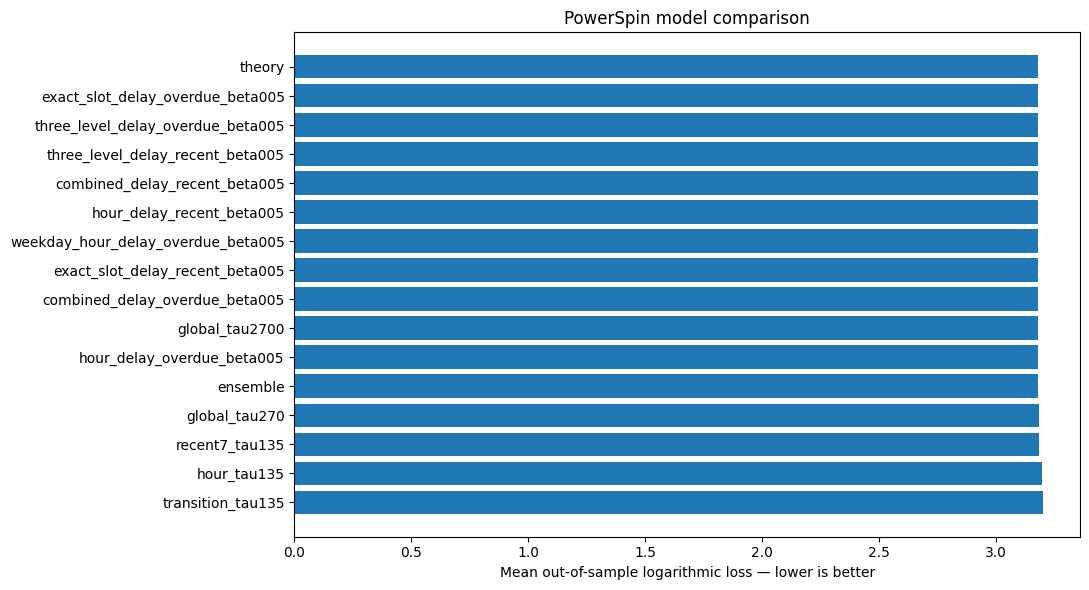

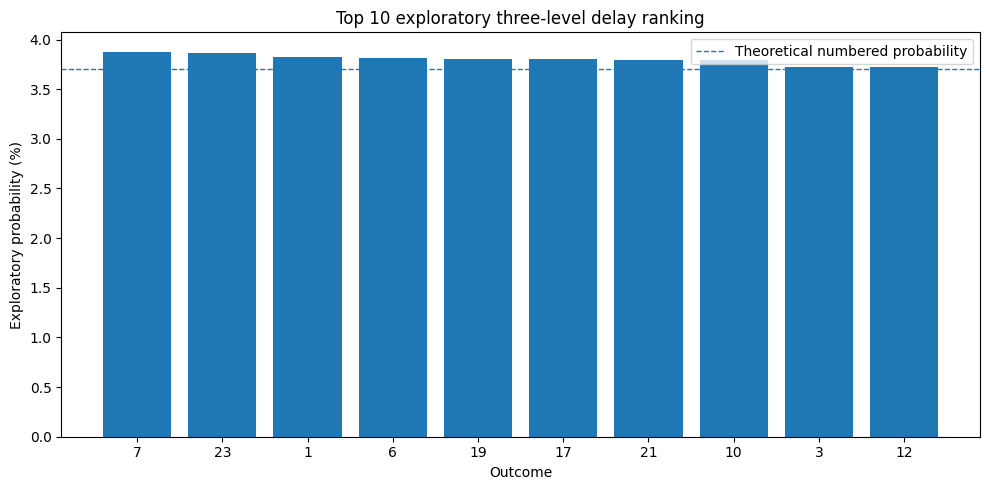

In [6]:
plot_df = backtest_df.sort_values('mean_log_loss').copy()

plt.figure(figsize=(11, 6))
plt.barh(plot_df['model'], plot_df['mean_log_loss'])
plt.gca().invert_yaxis()
plt.xlabel('Mean out-of-sample logarithmic loss — lower is better')
plt.title('PowerSpin model comparison')
plt.tight_layout()
plt.show()

numbered = probability_df[probability_df['outcome'].astype(str) != 'SYMBOL'].copy()
numbered = numbered.nsmallest(10, 'three_level_delay_overdue_rank')

plt.figure(figsize=(10, 5))
plt.bar(numbered['outcome'].astype(str), numbered['three_level_delay_overdue_probability'] * 100)
plt.axhline(100 / 27, linestyle='--', linewidth=1, label='Theoretical numbered probability')
plt.xlabel('Outcome')
plt.ylabel('Exploratory probability (%)')
plt.title('Top 10 exploratory three-level delay ranking')
plt.legend()
plt.tight_layout()
plt.show()



## 7. Create and download the result archive

The archive contains all generated CSV and JSON outputs. Set `AUTO_DOWNLOAD_RESULTS = True` in the configuration cell for an automatic browser download after running this cell.


In [7]:
archive_base = ROOT / 'powerspin_colab_results_v3'
archive_path = Path(shutil.make_archive(str(archive_base), 'zip', root_dir=OUTPUT_DIR))
print(f'Created: {archive_path} ({archive_path.stat().st_size:,} bytes)')

if AUTO_DOWNLOAD_RESULTS:
    try:
        from google.colab import files
        files.download(str(archive_path))
    except ImportError:
        print('Automatic download is available only in Google Colab.')
else:
    print('Set AUTO_DOWNLOAD_RESULTS = True and rerun this cell to download automatically.')


Created: /content/powerspin_colab/powerspin_colab_results_v3.zip (63,948 bytes)
Set AUTO_DOWNLOAD_RESULTS = True and rerun this cell to download automatically.



## Input requirements for future runs

### Panorama text

The panorama must retain the original tab-separated layout:

- one row per scheduled time (`08:01`, `08:05`, …, `23:57`);
- first date column is the date entered in `LATEST_DATE`;
- blank cell = `SYMBOL`;
- hyphen (`-`) = scheduled draw not yet completed;
- integer = numbered outcome from 1 through 24.

### Supplemental draws CSV

Required columns:

```text
datetime,outcome
```

`outcome` may be `SYMBOL` or an integer from 1 through 24.

### Hour and weekday-hour snapshots

Required columns:

```text
hour_band,SYMBOL,1,2,...,24
```

### Exact four-minute snapshot

Required columns:

```text
draw_time,SYMBOL,1,2,...,24
```

Partial exact-slot coverage is allowed. Every supplied row must contain exactly one zero.
